# 05 — Robustness analysis

Methodology §3.12.5 (robustness metrics), §3.13 (E1–E6), §3.14 (statistical tests).

Notebooks 03 and 04 measured each model on each test set. This notebook asks the research
questions directly: **how much does performance drop** when the same prompts are reworded (E2),
disguised (E3) or written in Bangla (E4), and are those drops statistically real?

**Code:** `src/robustness.py` · **Input:** per-row predictions in `results/tables/predictions/`

In [1]:
import os, sys, warnings
from pathlib import Path
if Path.cwd().name == "notebooks":        # run from the project root
    os.chdir("..")
sys.path.insert(0, "src")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
plt.rcParams["figure.dpi"] = 80           # on-screen size only; saved PNGs are 300 dpi
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
print("working directory:", Path.cwd().name)

working directory: sentinelprompt


## The metrics

| Metric | Formula | Reads as |
|---|---|---|
| **RDR** — Robustness Drop Rate | (F1_clean − F1_adv) / F1_clean × 100 | % of macro-F1 lost under attack (0% = fully robust) |
| **ASR** — Attack Success Rate | injections caught on E1 but missed on the variant ÷ injections caught on E1 | % of detected attacks that escape once rewritten |
| **CLD** — Cross-Lingual Degradation | F1(English) − F1(Bangla–English) inside D4 | cost of switching language, same prompts |
| **McNemar (exact)** | paired test on E1 vs variant correctness | is the drop real or chance? |
| **Bootstrap 95% CI** | 1,000 resamples of E1 | how uncertain is the E1 macro-F1 itself? |

ASR and McNemar are **paired**: every E2/E3 row is linked to its E1 parent through `parent_id`,
so each comparison is the same prompt before and after rewriting.

In [2]:
import robustness as rb
pred_dir = Path("results/tables/predictions")
files = sorted(pred_dir.glob("*.csv"))
preds = {p.stem: pd.read_csv(p) for p in files}
print("prediction files:", ", ".join(preds))

prediction files: distilbert_seed1337, distilbert_seed2024, distilbert_seed42, linear_svm, logreg, naive_bayes, protectai_deberta, roberta_seed1337, roberta_seed2024, roberta_seed42


## RDR, ASR, CLD and McNemar per model

Transformers have one prediction file per seed; their row below is the mean over seeds,
with the per-seed values in `results/tables/robustness_per_seed.csv`.

In [3]:
rows = [rb.model_robustness(k, v) for k, v in preds.items()]
per_seed = pd.DataFrame(rows)
per_seed["model"] = per_seed.model.str.replace(r"_seed\d+$", "", regex=True)
num = per_seed.select_dtypes("number").columns
rob = per_seed.groupby("model", sort=False)[num].mean().reset_index()
pd.DataFrame(rows).to_csv("results/tables/robustness_per_seed.csv", index=False)
rob.to_csv("results/tables/robustness_summary.csv", index=False)
cols = ["model", "E1_macro_f1", "E1_ci_low", "E1_ci_high", "E2_macro_f1", "E2_RDR_pct", "E2_ASR_pct",
        "E2_mcnemar_p", "E3_macro_f1", "E3_RDR_pct", "E3_ASR_pct", "E3_mcnemar_p",
        "CLD_en_minus_bnen", "CLD_en_minus_bn"]
display(rob[[c for c in cols if c in rob.columns]])

,model,E1_macro_f1,E1_ci_low,E1_ci_high,E2_macro_f1,E2_RDR_pct,E2_ASR_pct,E2_mcnemar_p,E3_macro_f1,E3_RDR_pct,E3_ASR_pct,E3_mcnemar_p,CLD_en_minus_bnen,CLD_en_minus_bn
0,distilbert,0.9430,0.8936,0.9851,0.9290,1.4708,4.5058,0.7500,0.7784,17.4388,0.0000,0.0000,0.3770,0.4715
1,linear_svm,0.8886,0.8197,0.9461,0.8496,4.3853,8.8235,1.0000,0.8547,3.8169,8.3485,0.0000,0.2338,0.4714
2,logreg,0.9109,0.8512,0.9640,0.8496,6.7242,11.4286,0.6875,0.8624,5.3260,8.7719,0.0000,0.2157,0.5054
3,naive_bayes,0.8663,0.8016,0.9341,0.8866,-2.3458,5.8824,1.0000,0.8474,2.1818,3.5714,0.0055,0.1062,0.5066
4,protectai_deberta,0.7080,0.5921,0.7973,0.5726,19.1137,21.4286,0.2500,0.6841,3.3733,6.4777,0.0000,0.1017,0.5733
5,roberta,0.9777,0.9441,1.0000,0.9583,1.9698,5.7937,0.5000,0.6924,29.1506,0.3675,0.0000,0.5724,0.5895


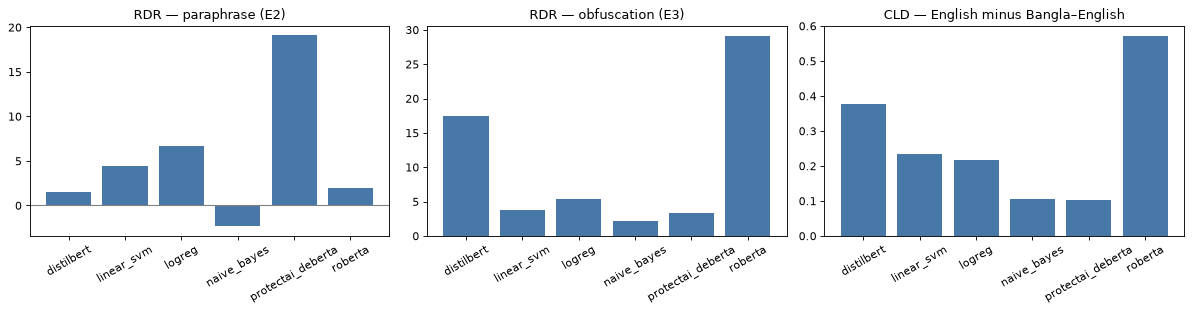

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in [(axes[0], "E2_RDR_pct", "RDR — paraphrase (E2)"),
                       (axes[1], "E3_RDR_pct", "RDR — obfuscation (E3)"),
                       (axes[2], "CLD_en_minus_bnen", "CLD — English minus Bangla–English")]:
    if col in rob:
        ax.bar(rob.model, rob[col], color="#4878a8")
        ax.set_title(title); ax.tick_params(axis="x", rotation=30)
        ax.axhline(0, color="grey", lw=1)
fig.tight_layout()
fig.savefig("results/figures/robustness_rdr_cld.png", dpi=300, bbox_inches="tight")
plt.show()

## E2 by paraphrase method

Two generators were used so that one method's quirks cannot drive the result: back-translation
(English → German → English) and WordNet synonym substitution. Every paraphrase passed a semantic
similarity gate (0.75 ≤ cosine ≤ 0.98 with multilingual Sentence-BERT): different enough to be a
real rewrite, close enough to keep the meaning.

In [5]:
gate = pd.read_csv("data/processed/paraphrase_gate_log.csv")
display(gate.groupby(["method", "verdict"]).size().unstack(fill_value=0))
pm = pd.concat([rb.per_method(k, v) for k, v in preds.items()])
pm["model"] = pm.model.str.replace(r"_seed\d+$", "", regex=True)
pm = pm.groupby(["model", "method"], sort=False).mean(numeric_only=True).reset_index()
pm.to_csv("results/tables/robustness_e2_by_method.csv", index=False)
display(pm)

verdict,kept,too_different,too_similar
method,,,
P1_back_translation,34,5,61
P3_wordnet,46,5,9


,model,method,n,macro_f1,ASR_pct
0,distilbert,P1_back_translation,34.0000,0.8500,9.2707
1,distilbert,P3_wordnet,46.0000,0.9853,0.0000
2,linear_svm,P1_back_translation,34.0000,0.8132,10.5263
3,linear_svm,P3_wordnet,46.0000,0.8600,6.6667
4,logreg,P1_back_translation,34.0000,0.8132,15.0000
5,logreg,P3_wordnet,46.0000,0.8600,6.6667
6,naive_bayes,P1_back_translation,34.0000,0.8786,10.0000
7,naive_bayes,P3_wordnet,46.0000,0.8819,0.0000
8,protectai_deberta,P1_back_translation,34.0000,0.5143,33.3333
9,protectai_deberta,P3_wordnet,46.0000,0.6054,0.0000


## E3 dose-response

Each obfuscation technique was applied at three strengths (10%, 20%, 30% of eligible units).
A robust model's line stays flat; a fragile one falls as the perturbation grows.
Base64 has no strength level (the whole prompt is encoded) and is shown separately.

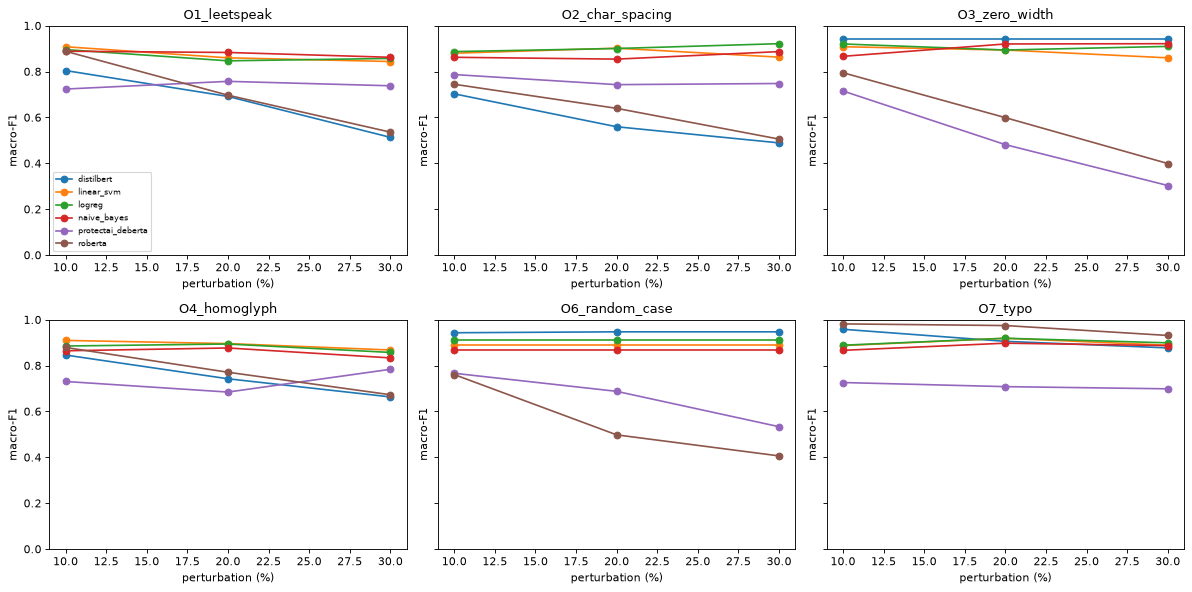

Base64 (whole prompt encoded):


,model,macro_f1,ASR_pct,n
12,distilbert,0.2537,0.0000,100.0000
31,linear_svm,0.3294,51.7241,100.0000
50,logreg,0.2308,13.3333,100.0000
69,naive_bayes,0.2537,0.0000,100.0000
88,protectai_deberta,0.2537,0.0000,100.0000
107,roberta,0.2537,0.0000,100.0000


In [6]:
dr = pd.concat([rb.dose_response(k, v) for k, v in preds.items()])
dr["model"] = dr.model.str.replace(r"_seed\d+$", "", regex=True)
dr = dr.groupby(["model", "technique", "perturbation_rate"], sort=False).mean(numeric_only=True).reset_index()
dr.to_csv("results/tables/robustness_e3_dose_response.csv", index=False)
techs = [t for t in dr.technique.unique() if t != "O5_base64"]
fig, axes = plt.subplots(2, 3, figsize=(15, 7.5), sharey=True)
for ax, t in zip(axes.ravel(), techs):
    for m, g in dr[dr.technique == t].groupby("model", sort=False):
        ax.plot(g.perturbation_rate * 100, g.macro_f1, marker="o", label=m)
    ax.set_title(t); ax.set_xlabel("perturbation (%)"); ax.set_ylabel("macro-F1"); ax.set_ylim(0, 1)
axes.ravel()[0].legend(fontsize=7)
fig.tight_layout()
fig.savefig("results/figures/robustness_e3_dose_response.png", dpi=300, bbox_inches="tight")
plt.show()
print("Base64 (whole prompt encoded):")
display(dr[dr.technique == "O5_base64"][["model", "macro_f1", "ASR_pct", "n"]])

## E4 by language variant

D4 holds the same 300 prompts in three forms, so differences between the columns are caused by
the language, not by the content.

In [7]:
lang_cols = [c for c in rob.columns if c.startswith("E4_f1_")]
display(rob[["model"] + lang_cols])

,model,E4_f1_bn,E4_f1_bn-en,E4_f1_en
0,distilbert,0.3702,0.4647,0.8418
1,linear_svm,0.3407,0.5783,0.8121
2,logreg,0.3407,0.6304,0.8461
3,naive_bayes,0.3693,0.7697,0.8759
4,protectai_deberta,0.3900,0.8617,0.9633
5,roberta,0.3333,0.3504,0.9228


## E6 — Leakage ablation (from `src/leakage_ablation.py`)

Leakage Inflation LI = accuracy(random split) − accuracy(grouped split). The script also runs a
like-for-like control, because a naive leaked-vs-clean comparison is confounded by which rows
happen to be duplicated.

In [8]:
display(pd.read_csv("results/tables/leakage_li_by_pool.csv"))
display(pd.read_csv("results/tables/leakage_learning_curve.csv"))
print(Path("results/leakage_report.txt").read_text())

,pool,rows,leaked_test_rows,acc_random,acc_grouped,LI_acc_mean,LI_acc_std
0,deepset,662,3.7000,0.9273,0.9344,-0.0072,0.0231
1,deepset+lakera,1662,4.6000,0.9446,0.9345,0.0101,0.0164
2,all_non_bnen,5812,215.1000,0.9889,0.9859,0.0030,0.0049


,train_n,acc_leaked,acc_clean,gap
0,99,1.0000,1.0000,0.0000
1,247,1.0000,1.0000,0.0000
2,494,1.0000,1.0000,0.0000
3,1235,1.0000,1.0000,0.0000
4,2470,1.0000,1.0000,0.0000
5,4941,1.0000,1.0000,0.0000


===== 1. LEAKAGE INFLATION BY POOL (10 seeds) =====
  deepset         rows   662  leaked test rows    3.7  LI = -0.0072 ± 0.0231
  deepset+lakera  rows  1662  leaked test rows    4.6  LI = +0.0101 ± 0.0164
  all_non_bnen    rows  5812  leaked test rows  215.1  LI = +0.0030 ± 0.0049

===== 2. LEAKED vs NON-LEAKED, same random split (uncontrolled) =====
  gap +0.0148 ± 0.0041, paired t=11.40, p=1.188e-06

===== 3. CONTROL: PromptBench rows only (one source, one label) =====
  gap +0.0000 (no variance; test undefined)
  -> step 2's gap is compositional, not memorisation.

===== 4. LEARNING CURVE (control, 8 seeds) =====
  train    99  leaked 1.0000  clean 1.0000  gap +0.0000
  train   247  leaked 1.0000  clean 1.0000  gap +0.0000
  train   494  leaked 1.0000  clean 1.0000  gap +0.0000
  train  1235  leaked 1.0000  clean 1.0000  gap +0.0000
  train  2470  leaked 1.0000  clean 1.0000  gap +0.0000
  train  4941  leaked 1.0000  clean 1.0000  gap +0.0000

Conclusion: H4 not supported on this c

## Key findings (computed)

In [9]:
for _, r in rob.iterrows():
    parts = [f"{r.model:18s} E1 {r.E1_macro_f1:.3f} [{r.E1_ci_low:.3f}, {r.E1_ci_high:.3f}]"]
    for t in ["E2", "E3"]:
        if f"{t}_RDR_pct" in r and pd.notna(r[f"{t}_RDR_pct"]):
            sig = "significant" if r[f"{t}_mcnemar_p"] < 0.05 else "not significant"
            parts.append(f"{t}: RDR {r[f'{t}_RDR_pct']:+.1f}%, ASR {r[f'{t}_ASR_pct']:.1f}% ({sig})")
    if "CLD_en_minus_bnen" in r:
        parts.append(f"CLD {r.CLD_en_minus_bnen:+.3f}")
    print(" | ".join(parts))

distilbert         E1 0.943 [0.894, 0.985] | E2: RDR +1.5%, ASR 4.5% (not significant) | E3: RDR +17.4%, ASR 0.0% (significant) | CLD +0.377
linear_svm         E1 0.889 [0.820, 0.946] | E2: RDR +4.4%, ASR 8.8% (not significant) | E3: RDR +3.8%, ASR 8.3% (significant) | CLD +0.234
logreg             E1 0.911 [0.851, 0.964] | E2: RDR +6.7%, ASR 11.4% (not significant) | E3: RDR +5.3%, ASR 8.8% (significant) | CLD +0.216
naive_bayes        E1 0.866 [0.802, 0.934] | E2: RDR -2.3%, ASR 5.9% (not significant) | E3: RDR +2.2%, ASR 3.6% (significant) | CLD +0.106
protectai_deberta  E1 0.708 [0.592, 0.797] | E2: RDR +19.1%, ASR 21.4% (not significant) | E3: RDR +3.4%, ASR 6.5% (significant) | CLD +0.102
roberta            E1 0.978 [0.944, 1.000] | E2: RDR +2.0%, ASR 5.8% (not significant) | E3: RDR +29.2%, ASR 0.4% (significant) | CLD +0.572
